In [1]:
from pathlib import Path
from collections import Counter


from sklearn.model_selection import train_test_split

from pathlib import Path
from datetime import datetime
import json

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_fscore_support,
    precision_recall_curve,
    average_precision_score
)
from sklearn.preprocessing import label_binarize

In [2]:
CLASS_NAMES = ["24", "48", "72", "healthy"]
NUM_CLASSES = len(CLASS_NAMES)

MODEL_SIZE = 512
SEED = 42
FORCE_GRAYSCALE = True

tf.random.set_seed(SEED)
np.random.seed(SEED)

EXPERIMENT_ROOT = Path("experiments")
EXPERIMENT_ROOT.mkdir(exist_ok=True)

RUN_ID = f"VGG16_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
EXP_DIR = EXPERIMENT_ROOT / RUN_ID

CHECKPOINT_DIR = EXP_DIR / "checkpoints"
PLOTS_DIR = EXP_DIR / "plots"
REPORTS_DIR = EXP_DIR / "reports"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Experiment:", RUN_ID)
print("Output directory:", EXP_DIR)

Experiment: VGG16_20260419_185227
Output directory: experiments\VGG16_20260419_185227


In [3]:
DATA_ROOT = Path(r"D:\\cells\\ML\\HEP2_png")

CLASS_NAMES = ["24", "48", "72", "control"]
CLASS_TO_IDX = {class_name: idx for idx, class_name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {idx: class_name for class_name, idx in CLASS_TO_IDX.items()}

IMG_SIZE = 512
BATCH_SIZE = 8
SEED = 42

# Если RAM мало, можно поставить False
USE_CACHE = True

AUTOTUNE = tf.data.AUTOTUNE

tf.random.set_seed(SEED)
np.random.seed(SEED)

print(CLASS_TO_IDX)

{'24': 0, '48': 1, '72': 2, 'control': 3}


In [4]:
rows = []

for class_name in CLASS_NAMES:
    class_dir = DATA_ROOT / class_name

    if not class_dir.exists():
        raise FileNotFoundError(f"Не найдена папка класса: {class_dir}")

    image_paths = sorted(class_dir.glob("*.png"))

    if len(image_paths) == 0:
        raise RuntimeError(f"В папке {class_dir} нет PNG-изображений")

    for path in image_paths:
        rows.append({
            "path": str(path),
            "class": class_name,
            "label": CLASS_TO_IDX[class_name]
        })

df = pd.DataFrame(rows)

print("Всего изображений:", len(df))
df.head()

Всего изображений: 827


,path,class,label
0,D:\cells\ML\HEP2_png\24\TUC-20251219092727377.png,24,0
1,D:\cells\ML\HEP2_png\24\TUC-20251219092733486.png,24,0
2,D:\cells\ML\HEP2_png\24\TUC-20251219092737240.png,24,0
3,D:\cells\ML\HEP2_png\24\TUC-20251219092741404.png,24,0
4,D:\cells\ML\HEP2_png\24\TUC-20251219092745351.png,24,0


In [5]:
class_counts = (
    df["class"]
    .value_counts()
    .reindex(CLASS_NAMES)
    .fillna(0)
    .astype(int)
)

print(class_counts)

class
24         269
48         128
72          86
control    344
Name: count, dtype: int32


In [6]:
df_train, df_temp = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label"]
)

df_val, df_test = train_test_split(
    df_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=df_temp["label"]
)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print("train:", len(df_train))
print("val:  ", len(df_val))
print("test: ", len(df_test))

train: 578
val:   124
test:  125


In [7]:
def show_split_distribution(name, split_df):
    counts = (
        split_df["class"]
        .value_counts()
        .reindex(CLASS_NAMES)
        .fillna(0)
        .astype(int)
    )

    print(f"\n{name}")
    print(counts)
    return counts


train_counts = show_split_distribution("TRAIN", df_train)
val_counts = show_split_distribution("VAL", df_val)
test_counts = show_split_distribution("TEST", df_test)


TRAIN
class
24         188
48          90
72          60
control    240
Name: count, dtype: int32

VAL
class
24         40
48         19
72         13
control    52
Name: count, dtype: int32

TEST
class
24         41
48         19
72         13
control    52
Name: count, dtype: int32


In [8]:
n_train = int(train_counts.sum())
n_classes = len(CLASS_NAMES)

class_weight_dict = {}

for class_name in CLASS_NAMES:
    class_idx = CLASS_TO_IDX[class_name]
    count = int(train_counts[class_name])

    if count == 0:
        raise RuntimeError(f"В train нет изображений класса {class_name}")

    weight = n_train / (n_classes * count)
    class_weight_dict[int(class_idx)] = float(weight)

print("class_weight_dict:")
for idx, weight in class_weight_dict.items():
    print(f"{idx} ({IDX_TO_CLASS[idx]}): {weight:.4f}")

class_weight_dict:
0 (24): 0.7686
1 (48): 1.6056
2 (72): 2.4083
3 (control): 0.6021


In [9]:
def load_image_grayscale_rgb(path, label):
    image_bytes = tf.io.read_file(path)

    image = tf.io.decode_png(
        image_bytes,
        channels=3
    )

    image = tf.cast(image, tf.float32)

    # RGB -> grayscale -> RGB
    # На выходе 3 канала, но изображение остаётся чёрно-белым.
    image = tf.image.rgb_to_grayscale(image)
    image = tf.image.grayscale_to_rgb(image)

    image = tf.image.resize(
        image,
        size=(IMG_SIZE, IMG_SIZE),
        method="bilinear"
    )

    label = tf.cast(label, tf.int32)

    return image, label

In [10]:
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomContrast(0.10),
], name="train_augmentation")

In [11]:
def apply_train_augmentation(images, labels):
    images = augmentation(images, training=True)
    return images, labels

In [12]:
train_paths = df_train["path"].values
train_labels = df_train["label"].values.astype(np.int32)

val_paths = df_val["path"].values
val_labels = df_val["label"].values.astype(np.int32)

test_paths = df_test["path"].values
test_labels = df_test["label"].values.astype(np.int32)

In [13]:
train_ds_base = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
val_ds_base = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
test_ds_base = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))

In [14]:
train_ds = train_ds_base.map(
    load_image_grayscale_rgb,
    num_parallel_calls=AUTOTUNE
)

if USE_CACHE:
    train_ds = train_ds.cache()

train_ds = (
    train_ds
    .shuffle(buffer_size=len(df_train), seed=SEED, reshuffle_each_iteration=True)
    .batch(BATCH_SIZE)
    .map(apply_train_augmentation, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

val_ds = val_ds_base.map(
    load_image_grayscale_rgb,
    num_parallel_calls=AUTOTUNE
)

if USE_CACHE:
    val_ds = val_ds.cache()

val_ds = (
    val_ds
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = test_ds_base.map(
    load_image_grayscale_rgb,
    num_parallel_calls=AUTOTUNE
)

if USE_CACHE:
    test_ds = test_ds.cache()

test_ds = (
    test_ds
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [15]:
for images, labels in train_ds.take(1):
    print("train images:", images.shape, images.dtype)
    print("train labels:", labels.shape, labels.numpy())
    print("pixel min:", tf.reduce_min(images).numpy())
    print("pixel max:", tf.reduce_max(images).numpy())

train images: (8, 512, 512, 3) <dtype: 'float32'>
train labels: (8,) [0 3 3 3 3 0 0 3]
pixel min: 0.0
pixel max: 243.27707


In [16]:
for images, labels in train_ds.take(1):
    print("images shape:", images.shape)
    print("images dtype:", images.dtype)
    print("labels shape:", labels.shape)
    print("labels example:", labels.numpy()[:10])
    print("pixel min:", tf.reduce_min(images).numpy())
    print("pixel max:", tf.reduce_max(images).numpy())

    INPUT_CHANNELS = images.shape[-1]
    PIXEL_MAX = float(tf.reduce_max(images).numpy())

print("INPUT_CHANNELS:", INPUT_CHANNELS)
print("PIXEL_MAX:", PIXEL_MAX)

if INPUT_CHANNELS != 3:
    raise ValueError(
        f"DenseNet121 ожидает 3 канала. Сейчас каналов: {INPUT_CHANNELS}. "
        "Проверьте подготовку датасета: grayscale должен быть продублирован в RGB."
    )

if "class_weight_dict" not in globals():
    raise RuntimeError("Не найдена переменная class_weight_dict.")

SCALE_0_1_TO_255 = PIXEL_MAX <= 1.5
print("SCALE_0_1_TO_255:", SCALE_0_1_TO_255)
print("class_weight_dict:")
print(class_weight_dict)
print("type:", type(class_weight_dict))

images shape: (8, 512, 512, 3)
images dtype: <dtype: 'float32'>
labels shape: (8,)
labels example: [3 0 0 3 3 2 3 0]
pixel min: 0.0
pixel max: 239.95955
INPUT_CHANNELS: 3
PIXEL_MAX: 239.9595489501953
SCALE_0_1_TO_255: False
class_weight_dict:
{0: 0.7686170212765957, 1: 1.6055555555555556, 2: 2.408333333333333, 3: 0.6020833333333333}
type: <class 'dict'>


In [17]:
from pathlib import Path
from datetime import datetime
import json

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

In [18]:
@tf.keras.utils.register_keras_serializable(package="custom")
class SparseMacroF1(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name="macro_f1", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = int(num_classes)

        self.cm = self.add_weight(
            name="confusion_matrix",
            shape=(self.num_classes, self.num_classes),
            initializer="zeros",
            dtype=tf.float32
        )

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.reshape(tf.cast(y_true, tf.int32), [-1])
        y_pred = tf.argmax(y_pred, axis=-1, output_type=tf.int32)

        cm_batch = tf.math.confusion_matrix(
            y_true,
            y_pred,
            num_classes=self.num_classes,
            dtype=tf.float32
        )

        self.cm.assign_add(cm_batch)

    def result(self):
        tp = tf.linalg.diag_part(self.cm)
        fp = tf.reduce_sum(self.cm, axis=0) - tp
        fn = tf.reduce_sum(self.cm, axis=1) - tp

        precision = tf.math.divide_no_nan(tp, tp + fp)
        recall = tf.math.divide_no_nan(tp, tp + fn)

        f1 = tf.math.divide_no_nan(
            2.0 * precision * recall,
            precision + recall
        )

        return tf.reduce_mean(f1)

    def reset_state(self):
        self.cm.assign(tf.zeros_like(self.cm))

    def get_config(self):
        config = super().get_config()
        config.update({"num_classes": self.num_classes})
        return config
    
@tf.keras.utils.register_keras_serializable(package="custom")
class SparseMacroAUC(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name="macro_auc", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = int(num_classes)

        self.auc = tf.keras.metrics.AUC(
            curve="ROC",
            multi_label=True,
            num_labels=self.num_classes,
            name=f"{name}_inner"
        )

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.reshape(tf.cast(y_true, tf.int32), [-1])
        y_true = tf.one_hot(y_true, depth=self.num_classes)

        self.auc.update_state(
            y_true,
            y_pred,
            sample_weight=sample_weight
        )

    def result(self):
        return self.auc.result()

    def reset_state(self):
        self.auc.reset_state()

    def get_config(self):
        config = super().get_config()
        config.update({"num_classes": self.num_classes})
        return config

@tf.keras.utils.register_keras_serializable(package="custom")
class SparseMacroPrecision(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name="macro_precision", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = int(num_classes)

        self.cm = self.add_weight(
            name="confusion_matrix",
            shape=(self.num_classes, self.num_classes),
            initializer="zeros",
            dtype=tf.float32
        )

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.reshape(tf.cast(y_true, tf.int32), [-1])
        y_pred = tf.argmax(y_pred, axis=-1, output_type=tf.int32)

        cm_batch = tf.math.confusion_matrix(
            y_true,
            y_pred,
            num_classes=self.num_classes,
            dtype=tf.float32
        )

        self.cm.assign_add(cm_batch)

    def result(self):
        tp = tf.linalg.diag_part(self.cm)
        fp = tf.reduce_sum(self.cm, axis=0) - tp

        precision = tf.math.divide_no_nan(tp, tp + fp)

        return tf.reduce_mean(precision)

    def reset_state(self):
        self.cm.assign(tf.zeros_like(self.cm))

    def get_config(self):
        config = super().get_config()
        config.update({"num_classes": self.num_classes})
        return config
    
@tf.keras.utils.register_keras_serializable(package="custom")
class SparseMacroRecall(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name="macro_recall", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = int(num_classes)

        self.cm = self.add_weight(
            name="confusion_matrix",
            shape=(self.num_classes, self.num_classes),
            initializer="zeros",
            dtype=tf.float32
        )

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.reshape(tf.cast(y_true, tf.int32), [-1])
        y_pred = tf.argmax(y_pred, axis=-1, output_type=tf.int32)

        cm_batch = tf.math.confusion_matrix(
            y_true,
            y_pred,
            num_classes=self.num_classes,
            dtype=tf.float32
        )

        self.cm.assign_add(cm_batch)

    def result(self):
        tp = tf.linalg.diag_part(self.cm)
        fn = tf.reduce_sum(self.cm, axis=1) - tp

        recall = tf.math.divide_no_nan(tp, tp + fn)

        return tf.reduce_mean(recall)

    def reset_state(self):
        self.cm.assign(tf.zeros_like(self.cm))

    def get_config(self):
        config = super().get_config()
        config.update({"num_classes": self.num_classes})
        return config

In [19]:
@tf.keras.utils.register_keras_serializable(package="custom")
class VGG16Preprocess(tf.keras.layers.Layer):
    def __init__(self, scale_0_1_to_255=False, **kwargs):
        super().__init__(**kwargs)
        self.scale_0_1_to_255 = bool(scale_0_1_to_255)

    def call(self, inputs):
        x = tf.cast(inputs, tf.float32)

        if self.scale_0_1_to_255:
            x = x * 255.0

        x = tf.keras.applications.vgg16.preprocess_input(x)

        return x

    def get_config(self):
        config = super().get_config()
        config.update({
            "scale_0_1_to_255": self.scale_0_1_to_255
        })
        return config

In [20]:
tf.keras.backend.clear_session()

from tensorflow.keras import layers, Model, regularizers

inputs = tf.keras.Input(
    shape=(MODEL_SIZE, MODEL_SIZE, 3),
    name="input_image"
)

x = VGG16Preprocess(
    scale_0_1_to_255=SCALE_0_1_TO_255,
    name="vgg16_preprocess"
)(inputs)

base = tf.keras.applications.VGG16(
    include_top=False,
    weights="imagenet",
    input_shape=(MODEL_SIZE, MODEL_SIZE, 3)
)

base.trainable = False

features = base(x, training=False)

gap = layers.GlobalAveragePooling2D(name="global_avg_pool")(features)
gmp = layers.GlobalMaxPooling2D(name="global_max_pool")(features)

x = layers.Concatenate(name="concat_avg_max_pool")([gap, gmp])

x = layers.LayerNormalization(
    epsilon=1e-6,
    name="head_layer_norm"
)(x)

x = layers.Dropout(
    0.45,
    name="dropout_1"
)(x)

x = layers.Dense(
    256,
    activation="relu",
    kernel_regularizer=regularizers.l2(1e-4),
    name="dense_head"
)(x)

x = layers.Dropout(
    0.35,
    name="dropout_2"
)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    kernel_regularizer=regularizers.l2(1e-4),
    name="classifier"
)(x)

model = Model(
    inputs=inputs,
    outputs=outputs,
    name="vgg16_hep2_classifier_precision_recall"
)

model.summary()

Model: "vgg16_hep2_classifier_precision_recall"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_preprocess    │ (None, 512, 512,  │          0 │ input_image[0][0] │
│ (VGG16Preprocess)   │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 16, 16,    │ 14,714,688 │ vgg16_preprocess… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_avg_pool     │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pool     │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_avg_max_pool │ (None, 1024)      │          0 │ global_avg_pool[… │
│ (Concatenate)       │                   │            │ global_max_pool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_layer_norm     │ (None, 1024)      │      2,048 │ concat_avg_max_p… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 1024)      │          0 │ head_layer_norm[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_head (Dense)  │ (None, 256)       │    262,400 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_head[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier (Dense)  │ (None, 4)         │      1,028 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,980,164 (57.14 MB)

 Trainable params: 265,476 (1.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [21]:
stage1_metrics = [
    tf.keras.metrics.SparseCategoricalAccuracy(name="acc"),
    tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top2_acc"),
    SparseMacroPrecision(num_classes=NUM_CLASSES, name="macro_precision"),
    SparseMacroRecall(num_classes=NUM_CLASSES, name="macro_recall"),
    SparseMacroF1(num_classes=NUM_CLASSES, name="macro_f1"),
    SparseMacroAUC(num_classes=NUM_CLASSES, name="macro_auc"),
]
try:
    optimizer_stage1 = tf.keras.optimizers.AdamW(
        learning_rate=2e-4,
        weight_decay=1e-4
    )
except AttributeError:
    optimizer_stage1 = tf.keras.optimizers.Adam(
        learning_rate=2e-4
    )

model.compile(
    optimizer=optimizer_stage1,
    loss="sparse_categorical_crossentropy",
    metrics=stage1_metrics
)

In [22]:
stage1_weights_path = CHECKPOINT_DIR / "best_stage1.weights.h5"

callbacks_stage1 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(stage1_weights_path),
        monitor="val_macro_f1",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_macro_f1",
        mode="max",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    tf.keras.callbacks.CSVLogger(
        filename=str(REPORTS_DIR / "stage1_training_log.csv")
    )
]

In [23]:
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weight_dict,
    callbacks=callbacks_stage1
)

Epoch 1/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - acc: 0.3903 - loss: 1.9470 - macro_auc: 0.6192 - macro_f1: 0.3440 - macro_precision: 0.3645 - macro_recall: 0.3551 - top2_acc: 0.6474
Epoch 1: val_macro_f1 improved from None to 0.58690, saving model to experiments\VGG16_20260419_185227\checkpoints\best_stage1.weights.h5

Epoch 1: finished saving model to experiments\VGG16_20260419_185227\checkpoints\best_stage1.weights.h5
73/73 ━━━━━━━━━━━━━━━━━━━━ 371s 5s/step - acc: 0.4671 - loss: 1.6386 - macro_auc: 0.6892 - macro_f1: 0.4064 - macro_precision: 0.4234 - macro_recall: 0.4149 - top2_acc: 0.7180 - val_acc: 0.7903 - val_loss: 0.6458 - val_macro_auc: 0.9430 - val_macro_f1: 0.5869 - val_macro_precision: 0.5556 - val_macro_recall: 0.6302 - val_top2_acc: 0.9113 - learning_rate: 2.0000e-04
Epoch 2/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - acc: 0.5879 - loss: 1.1256 - macro_auc: 0.8329 - macro_f1: 0.5263 - macro_precision: 0.5306 - macro_recall: 0.5367 - top2_acc: 0.8488
Epoch 2: val_macro_f

In [24]:
model.load_weights(stage1_weights_path)

base.trainable = True

for layer in base.layers:
    layer.trainable = False

# Размораживаем только последний блок VGG16
for layer in base.layers:
    if layer.name.startswith("block5"):
        layer.trainable = True

trainable_layers = sum(layer.trainable for layer in base.layers)

print("Backbone layers:", len(base.layers))
print("Trainable backbone layers:", trainable_layers)

for layer in base.layers:
    print(layer.name, layer.trainable)

Backbone layers: 19
Trainable backbone layers: 4
input_layer False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [25]:
stage2_metrics = [
    tf.keras.metrics.SparseCategoricalAccuracy(name="acc"),
    tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top2_acc"),
    SparseMacroPrecision(num_classes=NUM_CLASSES, name="macro_precision"),
    SparseMacroRecall(num_classes=NUM_CLASSES, name="macro_recall"),
    SparseMacroF1(num_classes=NUM_CLASSES, name="macro_f1"),
    SparseMacroAUC(num_classes=NUM_CLASSES, name="macro_auc"),
]
try:
    optimizer_stage2 = tf.keras.optimizers.AdamW(
        learning_rate=2e-6,
        weight_decay=1e-5
    )
except AttributeError:
    optimizer_stage2 = tf.keras.optimizers.Adam(
        learning_rate=2e-6
    )

model.compile(
    optimizer=optimizer_stage2,
    loss="sparse_categorical_crossentropy",
    metrics=stage2_metrics
)

In [26]:
stage2_weights_path = CHECKPOINT_DIR / "best_stage2.weights.h5"

callbacks_stage2 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(stage2_weights_path),
        monitor="val_macro_f1",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_macro_f1",
        mode="max",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.CSVLogger(
        filename=str(REPORTS_DIR / "stage2_training_log.csv")
    )
]

In [27]:
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weight_dict,
    callbacks=callbacks_stage2
)

Epoch 1/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - acc: 0.8676 - loss: 0.5956 - macro_auc: 0.9550 - macro_f1: 0.7846 - macro_precision: 0.7911 - macro_recall: 0.7871 - top2_acc: 0.9774
Epoch 1: val_macro_f1 improved from None to 0.80442, saving model to experiments\VGG16_20260419_185227\checkpoints\best_stage2.weights.h5

Epoch 1: finished saving model to experiments\VGG16_20260419_185227\checkpoints\best_stage2.weights.h5
73/73 ━━━━━━━━━━━━━━━━━━━━ 397s 5s/step - acc: 0.8599 - loss: 0.5790 - macro_auc: 0.9574 - macro_f1: 0.7775 - macro_precision: 0.7748 - macro_recall: 0.7810 - top2_acc: 0.9723 - val_acc: 0.8871 - val_loss: 0.3480 - val_macro_auc: 0.9738 - val_macro_f1: 0.8044 - val_macro_precision: 0.8227 - val_macro_recall: 0.8009 - val_top2_acc: 1.0000 - learning_rate: 2.0000e-06
Epoch 2/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - acc: 0.8448 - loss: 0.5349 - macro_auc: 0.9611 - macro_f1: 0.7458 - macro_precision: 0.7522 - macro_recall: 0.7474 - top2_acc: 0.9671
Epoch 2: val_macro_f

In [28]:
history_all = {}

for h in [history1, history2]:
    for key, values in h.history.items():
        if key not in history_all:
            history_all[key] = []
        history_all[key].extend(values)

stage1_epochs = len(history1.history["loss"])
total_epochs = len(history_all["loss"])

history_df = pd.DataFrame(history_all)
history_df.insert(0, "epoch", np.arange(1, total_epochs + 1))

history_df["stage"] = [
    "stage1" if i < stage1_epochs else "stage2"
    for i in range(total_epochs)
]

history_csv_path = REPORTS_DIR / "combined_training_history.csv"
history_df.to_csv(history_csv_path, index=False, encoding="utf-8-sig")

print("Saved:", history_csv_path)
history_df.head()

Saved: experiments\VGG16_20260419_185227\reports\combined_training_history.csv


,epoch,acc,loss,macro_auc,macro_f1,macro_precision,macro_recall,top2_acc,val_acc,val_loss,val_macro_auc,val_macro_f1,val_macro_precision,val_macro_recall,val_top2_acc,learning_rate,stage
0,1,0.467128,1.638604,0.689215,0.406429,0.423383,0.414894,0.717993,0.790323,0.645795,0.943019,0.586899,0.555614,0.630187,0.911290,0.0002,stage1
1,2,0.622837,1.067058,0.846950,0.541795,0.540573,0.554610,0.871972,0.838710,0.462407,0.966588,0.681705,0.838657,0.683856,0.959677,0.0002,stage1
2,3,0.692042,0.989060,0.879309,0.599304,0.599582,0.609050,0.887543,0.879032,0.435632,0.965691,0.707532,0.889178,0.750481,0.991935,0.0002,stage1
3,4,0.745675,0.794045,0.917337,0.655856,0.651792,0.665396,0.922145,0.854839,0.416041,0.968236,0.748027,0.752701,0.747444,0.983871,0.0002,stage1
4,5,0.785467,0.774467,0.924349,0.699034,0.695186,0.705194,0.937716,0.846774,0.410076,0.970293,0.736517,0.781690,0.765486,0.983871,0.0002,stage1


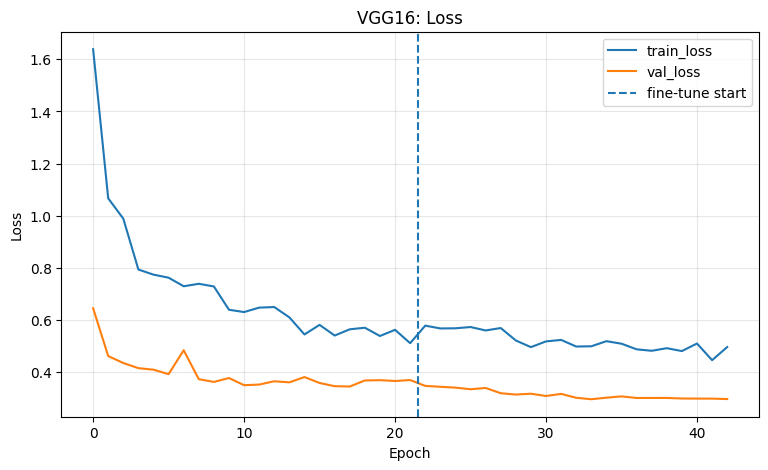

Saved: experiments\VGG16_20260419_185227\plots\loss_curve.png


In [29]:
plt.figure(figsize=(9, 5))

plt.plot(history_all["loss"], label="train_loss")
plt.plot(history_all["val_loss"], label="val_loss")

plt.axvline(
    stage1_epochs - 0.5,
    linestyle="--",
    label="fine-tune start"
)

plt.title("VGG16: Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

out_path = PLOTS_DIR / "loss_curve.png"
plt.savefig(out_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

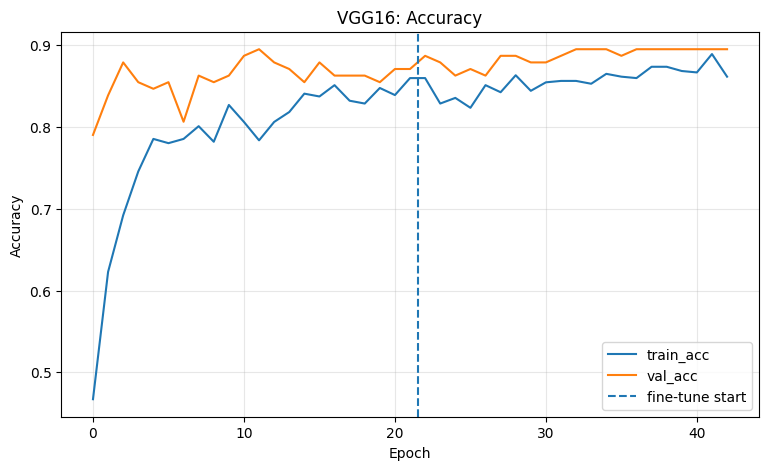

Saved: experiments\VGG16_20260419_185227\plots\accuracy_curve.png


In [30]:
plt.figure(figsize=(9, 5))

plt.plot(history_all["acc"], label="train_acc")
plt.plot(history_all["val_acc"], label="val_acc")

plt.axvline(
    stage1_epochs - 0.5,
    linestyle="--",
    label="fine-tune start"
)

plt.title("VGG16: Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

out_path = PLOTS_DIR / "accuracy_curve.png"
plt.savefig(out_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

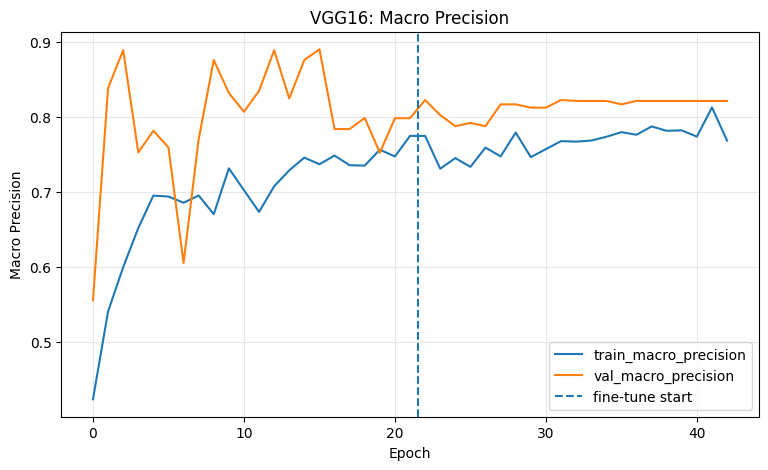

Saved: experiments\VGG16_20260419_185227\plots\macro_precision_curve.png


In [31]:
plt.figure(figsize=(9, 5))

plt.plot(history_all["macro_precision"], label="train_macro_precision")
plt.plot(history_all["val_macro_precision"], label="val_macro_precision")

plt.axvline(
    stage1_epochs - 0.5,
    linestyle="--",
    label="fine-tune start"
)

plt.title("VGG16: Macro Precision")
plt.xlabel("Epoch")
plt.ylabel("Macro Precision")
plt.legend()
plt.grid(True, alpha=0.3)

out_path = PLOTS_DIR / "macro_precision_curve.png"
plt.savefig(out_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

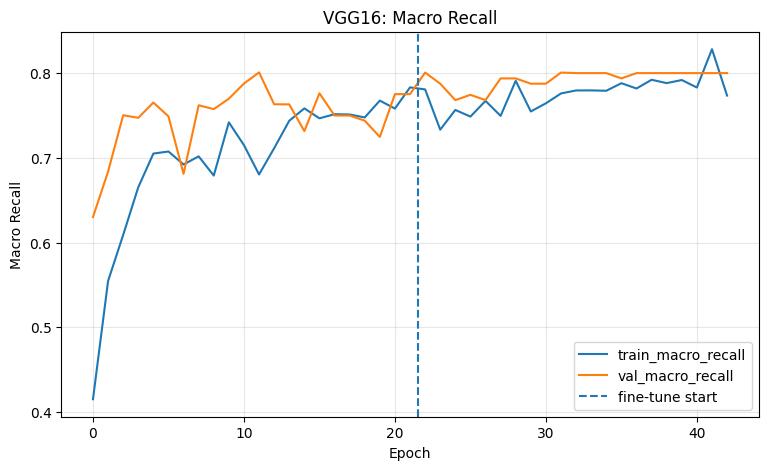

Saved: experiments\VGG16_20260419_185227\plots\macro_recall_curve.png


In [32]:
plt.figure(figsize=(9, 5))

plt.plot(history_all["macro_recall"], label="train_macro_recall")
plt.plot(history_all["val_macro_recall"], label="val_macro_recall")

plt.axvline(
    stage1_epochs - 0.5,
    linestyle="--",
    label="fine-tune start"
)

plt.title("VGG16: Macro Recall")
plt.xlabel("Epoch")
plt.ylabel("Macro Recall")
plt.legend()
plt.grid(True, alpha=0.3)

out_path = PLOTS_DIR / "macro_recall_curve.png"
plt.savefig(out_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

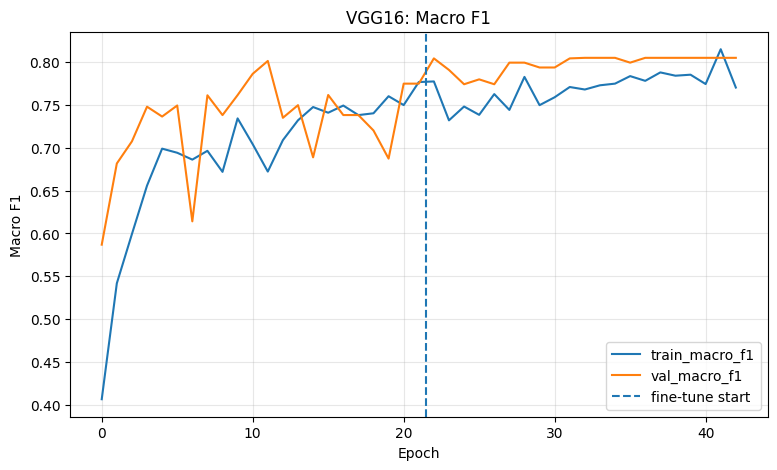

Saved: experiments\VGG16_20260419_185227\plots\macro_f1_curve.png


In [33]:
plt.figure(figsize=(9, 5))

plt.plot(history_all["macro_f1"], label="train_macro_f1")
plt.plot(history_all["val_macro_f1"], label="val_macro_f1")

plt.axvline(
    stage1_epochs - 0.5,
    linestyle="--",
    label="fine-tune start"
)

plt.title("VGG16: Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.legend()
plt.grid(True, alpha=0.3)

out_path = PLOTS_DIR / "macro_f1_curve.png"
plt.savefig(out_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

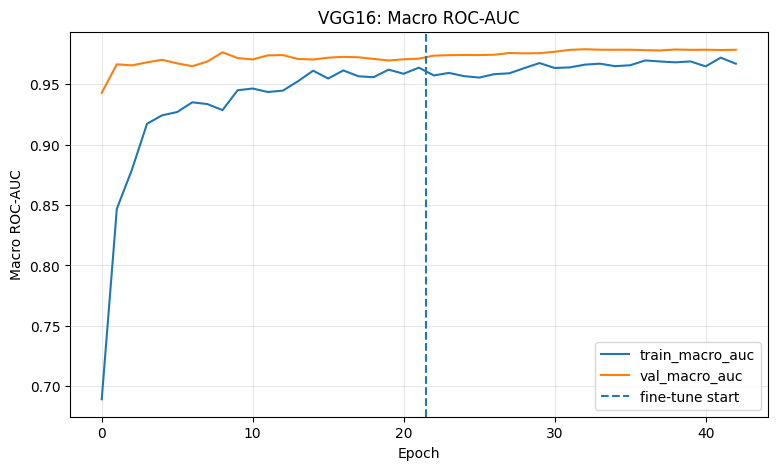

Saved: experiments\VGG16_20260419_185227\plots\macro_auc_curve.png


In [34]:
plt.figure(figsize=(9, 5))

plt.plot(history_all["macro_auc"], label="train_macro_auc")
plt.plot(history_all["val_macro_auc"], label="val_macro_auc")

plt.axvline(
    stage1_epochs - 0.5,
    linestyle="--",
    label="fine-tune start"
)

plt.title("VGG16: Macro ROC-AUC")
plt.xlabel("Epoch")
plt.ylabel("Macro ROC-AUC")
plt.legend()
plt.grid(True, alpha=0.3)

out_path = PLOTS_DIR / "macro_auc_curve.png"
plt.savefig(out_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

In [35]:
test_results = model.evaluate(test_ds, return_dict=True)

print("Test results:")
for key, value in test_results.items():
    print(f"{key}: {value:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 78s 5s/step - acc: 0.8560 - loss: 0.3571 - macro_auc: 0.9723 - macro_f1: 0.7650 - macro_precision: 0.7748 - macro_recall: 0.7610 - top2_acc: 0.9920
Test results:
acc: 0.8560
loss: 0.3571
macro_auc: 0.9723
macro_f1: 0.7650
macro_precision: 0.7748
macro_recall: 0.7610
top2_acc: 0.9920


In [36]:
y_true = []
y_prob = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)

    y_true.extend(labels.numpy().tolist())
    y_prob.extend(probs.tolist())

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = np.argmax(y_prob, axis=1)

print("y_true:", y_true.shape)
print("y_prob:", y_prob.shape)
print("y_pred:", y_pred.shape)

y_true: (125,)
y_prob: (125, 4)
y_pred: (125,)


In [37]:
report_text = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
)

print(report_text)

              precision    recall  f1-score   support

          24     0.9487    0.9024    0.9250        41
          48     0.6667    0.5263    0.5882        19
          72     0.5714    0.6154    0.5926        13
     control     0.9123    1.0000    0.9541        52

    accuracy                         0.8560       125
   macro avg     0.7748    0.7610    0.7650       125
weighted avg     0.8515    0.8560    0.8514       125



In [38]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(values_format="d", ax=ax)

plt.title("DenseNet121: Confusion Matrix")
plt.grid(False)

out_path = PLOTS_DIR / "confusion_matrix.png"
plt.savefig(out_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

NameError: name 'cm' is not defined

In [ ]:
per_class_precision, per_class_recall, per_class_f1, per_class_support = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=np.arange(NUM_CLASSES),
        zero_division=0
    )
)

per_class_df = pd.DataFrame({
    "class": CLASS_NAMES,
    "precision": per_class_precision,
    "recall": per_class_recall,
    "f1": per_class_f1,
    "support": per_class_support
})

per_class_path = REPORTS_DIR / "per_class_precision_recall_f1.csv"
per_class_df.to_csv(per_class_path, index=False, encoding="utf-8-sig")

print(per_class_df)
print("Saved:", per_class_path)

In [ ]:
per_class_precision, per_class_recall, per_class_f1, per_class_support = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=np.arange(NUM_CLASSES),
        zero_division=0
    )
)

per_class_df = pd.DataFrame({
    "class": CLASS_NAMES,
    "precision": per_class_precision,
    "recall": per_class_recall,
    "f1": per_class_f1,
    "support": per_class_support
})

per_class_path = REPORTS_DIR / "per_class_precision_recall_f1.csv"
per_class_df.to_csv(per_class_path, index=False, encoding="utf-8-sig")

print(per_class_df)
print("Saved:", per_class_path)

In [ ]:
x = np.arange(NUM_CLASSES)
width = 0.25

plt.figure(figsize=(10, 5))

plt.bar(
    x - width,
    per_class_df["precision"],
    width,
    label="Precision"
)

plt.bar(
    x,
    per_class_df["recall"],
    width,
    label="Recall"
)

plt.bar(
    x + width,
    per_class_df["f1"],
    width,
    label="F1"
)

plt.xticks(x, CLASS_NAMES)
plt.ylim(0, 1.05)

plt.title("DenseNet121: Per-class Precision / Recall / F1")
plt.xlabel("Class")
plt.ylabel("Score")
plt.legend()
plt.grid(axis="y", alpha=0.3)

out_path = PLOTS_DIR / "per_class_precision_recall_f1.png"
plt.savefig(out_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

In [ ]:
y_true_bin = label_binarize(
    y_true,
    classes=np.arange(NUM_CLASSES)
)

plt.figure(figsize=(8, 6))

per_class_auc = {}

for i, class_name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    class_auc = auc(fpr, tpr)
    per_class_auc[class_name] = float(class_auc)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} AUC={class_auc:.3f}"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="chance"
)

plt.title("DenseNet121: ROC Curves by Class")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, alpha=0.3)

out_path = PLOTS_DIR / "roc_curves_by_class.png"
plt.savefig(out_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

for cls, value in per_class_auc.items():
    print(f"{cls:>8}: {value:.4f}")

In [ ]:
plt.figure(figsize=(8, 6))

per_class_average_precision = {}

for i, class_name in enumerate(CLASS_NAMES):
    precision_curve, recall_curve, _ = precision_recall_curve(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    avg_precision = average_precision_score(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    per_class_average_precision[class_name] = float(avg_precision)

    plt.plot(
        recall_curve,
        precision_curve,
        label=f"{class_name} AP={avg_precision:.3f}"
    )

plt.title("DenseNet121: Precision-Recall Curves by Class")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.ylim(0, 1.05)
plt.xlim(0, 1.0)
plt.legend()
plt.grid(True, alpha=0.3)

out_path = PLOTS_DIR / "precision_recall_curves_by_class.png"
plt.savefig(out_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

for cls, value in per_class_average_precision.items():
    print(f"{cls:>8}: AP={value:.4f}")